## **Can Peter Actually Generalize?**
### **Understanding Overfitting, Validation, and How to Build Models That Work on New Tests**
- Author: Isaac Cobena
- Date: 03-02-2026
  
Last month, we built Peter's Brain — a neural network that could predict his test scores based on sleep and study habits. It learned from 100 days of data and seemed to work well.

But Maria had a nagging question:

> **"Okay, it predicts yesterday's scores perfectly. But will it work on *tomorrow's* test? Can Peter's Brain handle questions it's never seen before?"**

This is the uncomfortable truth about machine learning models:

> A model that memorizes Peter's past may fail completely on new tests.

If Peter studies old answer sheets and memorizes them word-for-word, he might ace yesterday's test. But give him new questions? He might collapse.

This is the central problem in machine learning:

**Generalization.**

Let's see what happens when Peter's Brain faces this challenge.
### **1. Setting Up Our Generalization Experiment**

First, let's recreate our data and split it properly:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### **2. The Peter Dataset: 100 Days of Learning**

Maria has been tracking Peter's performance on daily math quizzes. Each quiz has **three questions**, and she recorded:

- **Hours of sleep** the night before
- **Minutes studied** that morning
- **Previous day's score** (to capture momentum)
- **Today's score** (what we want to predict)

This is **supervised learning**. We have:

- **Inputs** ($x$): sleep hours, study minutes
- **Targets** ($y$): today's score

In [2]:
# Recreate Peter's data
np.random.seed(42)
n_days = 100

sleep_hours = np.random.normal(7, 1.5, n_days).clip(4, 10)
study_minutes = np.random.normal(30, 15, n_days).clip(0, 90)
prev_score = np.random.normal(75, 10, n_days).clip(40, 100)

true_weights = [2.5, 0.8, 0.3]
noise = np.random.normal(0, 5, n_days)

today_score = (true_weights[0] * sleep_hours + 
               true_weights[1] * (study_minutes / 10) + 
               true_weights[2] * (prev_score / 10) + 
               50 + noise).clip(40, 100)

peter_data = pd.DataFrame({
    'sleep_hours': sleep_hours,
    'study_minutes': study_minutes,
    'prev_score': prev_score,
    'today_score': today_score
})

### **Data Split**

In [3]:
# Prepare features and target
X = peter_data[['sleep_hours', 'study_minutes', 'prev_score']].values
y = peter_data['today_score'].values

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, random_state = 42)

print(f"Training samples: {len(X_train)} days")
print(f"Validation samples: {len(X_val)} days")
print("\nMaria's insight: 'We'll train on 70 days, test on 30 days Peter hasn't seen yet.'")

Training samples: 70 days
Validation samples: 30 days

Maria's insight: 'We'll train on 70 days, test on 30 days Peter hasn't seen yet.'


### **2. The Danger: When Peter Memorizes Instead of Learns**

Let's build a deliberately **overpowered model** — one with way more capacity than needed. This is like Peter trying to memorize every single detail of his past tests, including which questions were asked on which days.

In [4]:
# Build an intentionally overparameterized model
overfit_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation = 'relu', input_shape = (3,),
                          name = 'layer1_massive'),
    tf.keras.layers.Dense(256, activation = 'relu',
                          name = 'layer2_massive'),
    tf.keras.layers.Dense(256, activation = 'relu',
                          name = 'layer3_massive'),
    tf.keras.layers.Dense(256, activation = 'relu',
                          name = 'layer4_massive'),
    tf.keras.layers.Dense(1, name = 'output')
])

overfit_model.compile(optimizer = 'adam', loss = 'mse')

print("Overparameterized Model Architecture:")
print("="*60)
overfit_model.summary()
print(f"\nTotal parameters: {overfit_model.count_params():,}")
print("Maria: 'That's 200,000+ parameters for just 70 training days?!'")

C:\Users\Juliet\Documents\READY-PROJECT\RETAIL\myenv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Overparameterized Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ layer1_massive (Dense)               │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer2_massive (Dense)               │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer3_massive (Dense)               │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer4_massive (Dense)               │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 198,657 (776.00 KB)

 Trainable params: 198,657 (776.00 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 198,657
Maria: 'That's 200,000+ parameters for just 70 training days?!'


### **Training the Overfit Model**
Before training the model, we'll normalize the features

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

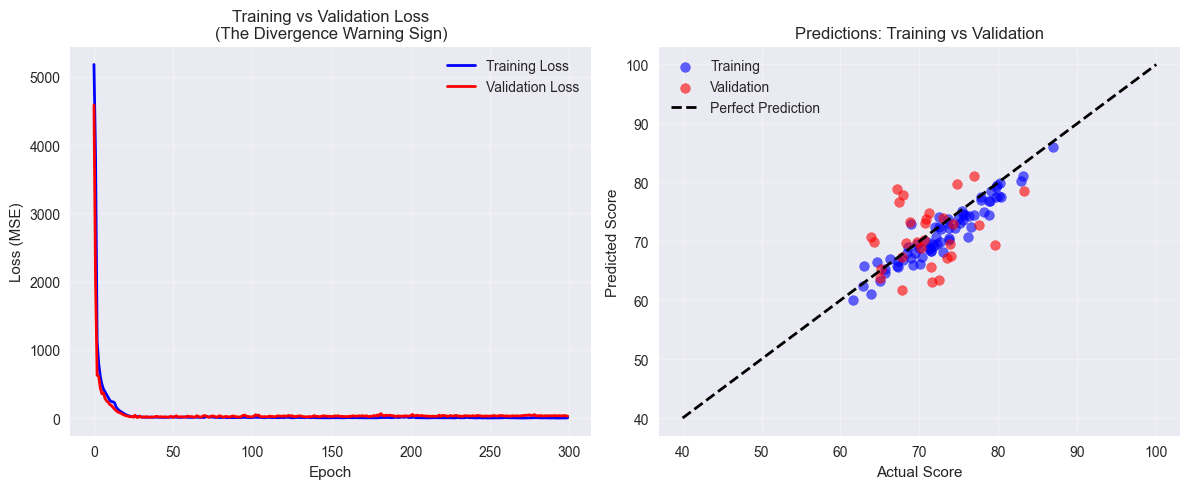

Final Training Loss: 6.56
Final Validation Loss: 32.22
Gap: 25.66


In [6]:
# Train for many epochs to encourage overfitting
history_overfit = overfit_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 300,
    verbose = 0,
    batch_size = 8
)

# Plot the results
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['loss'], 'b-', linewidth = 2, label = 'Training Loss')
plt.plot(history_overfit.history['val_loss'], 'r-', linewidth = 2, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss\n(The Divergence Warning Sign)')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1, 2, 2)
# Get predictions
train_pred = overfit_model.predict(X_train, verbose = 0)
val_pred = overfit_model.predict(X_val, verbose = 0)

plt.scatter(y_train, train_pred, alpha = 0.6, s = 50, label = 'Training', color = 'blue')
plt.scatter(y_val, val_pred, alpha = 0.6, s = 50, label = 'Validation', color = 'red')
plt.plot([40, 100], [40, 100], 'k--', linewidth = 2, label = 'Perfect Prediction')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Predictions: Training vs Validation')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

train_loss = history_overfit.history['loss'][-1]
val_loss = history_overfit.history['val_loss'][-1]
print(f"Final Training Loss: {train_loss:.2f}")
print(f"Final Validation Loss: {val_loss:.2f}")
print(f"Gap: {val_loss - train_loss:.2f}")

### **What Just Happened?**

Look at that gap! The model performs beautifully on training data but terribly on validation data.

**This is overfitting.**

The model didn't learn the underlying relationship between sleep, study, and test scores. Instead, it memorized:

- Which specific days Peter had coffee
- When he was distracted by video games
- The random noise in each measurement

It's like Peter memorizing the exact questions from his practice tests but having no idea how to solve new problems.

### **3. Training Loss vs Validation Loss: The Critical Distinction**

Let's define these concepts clearly:

| Metric | What It Measures | Peter Analogy |
|--------|------------------|---------------|
| **Training Loss** | How well did I memorize the past? | Peter acing last week's practice test |
| **Validation Loss** | How well will I perform on new material? | Peter taking a brand new test tomorrow |

Maria's realization:

> "If Peter only practices on the exact same questions, he might get 100% on practice tests but fail the real exam. **Validation loss tells me if he's actually learning or just memorizing.** "

### **4. Visualizing the Overfitting Process**

Let's watch overfitting happen in real-time:

C:\Users\Juliet\Documents\READY-PROJECT\RETAIL\myenv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


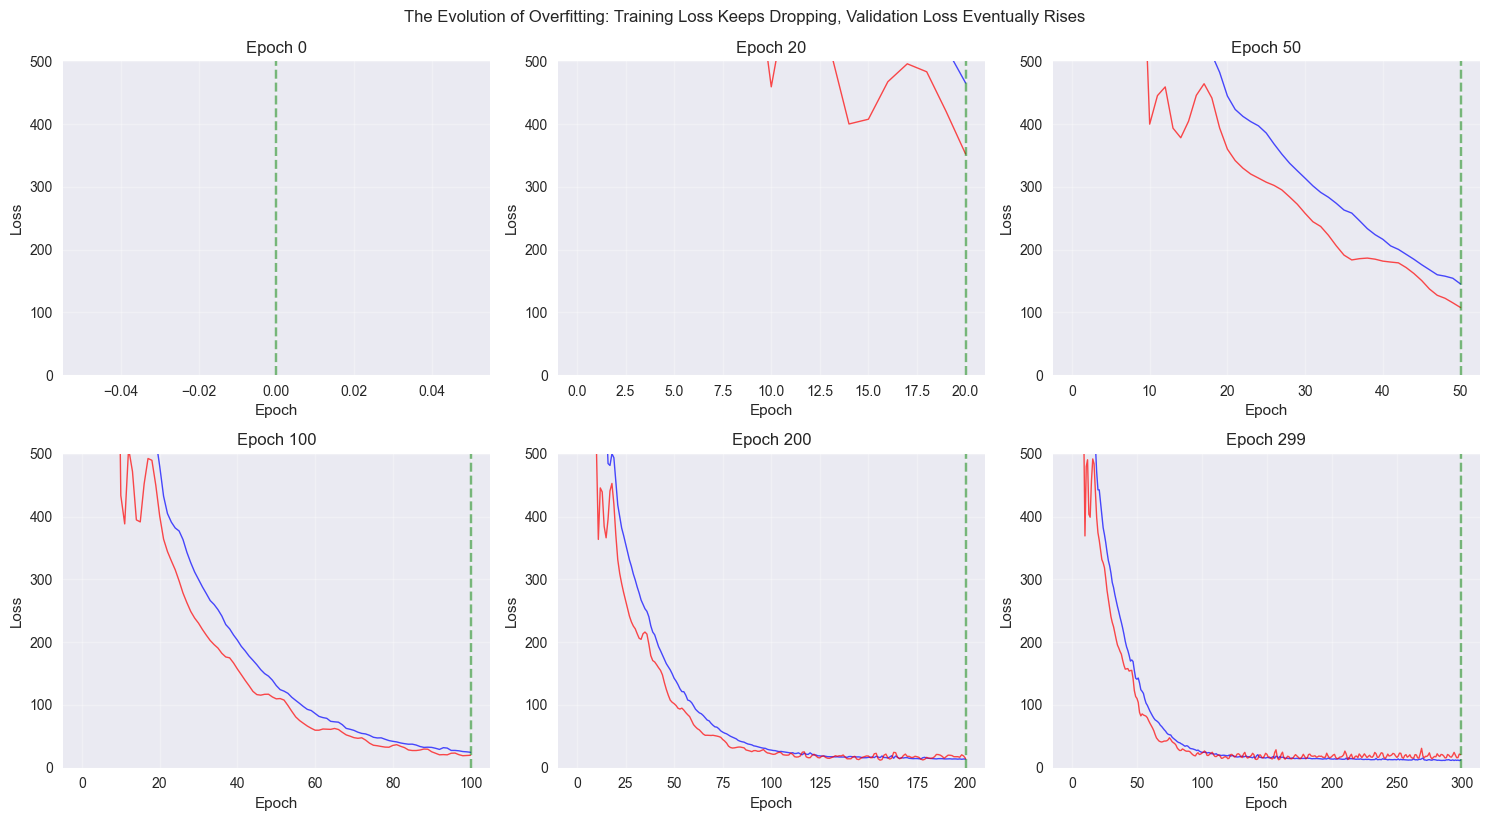

In [7]:
# Create a figure that evolves with training
fig, axes = plt.subplots(2, 3, figsize = (15, 8))
epochs_to_show = [0, 20, 50, 100, 200, 299]

for idx, epoch in enumerate(epochs_to_show):
    row, col = idx // 3, idx % 3
    
    # Get predictions at this epoch
    overfit_model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation = 'relu', input_shape = (3,)),
        tf.keras.layers.Dense(256, activation = 'relu'),
        tf.keras.layers.Dense(256, activation = 'relu'),
        tf.keras.layers.Dense(1)
    ])
    overfit_model.compile(optimizer = 'adam', loss = 'mse')
    
    # Train up to this epoch
    history = overfit_model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs = epoch+1,
        verbose = 0,
        initial_epoch = 0
    )
    
    # Plot training vs validation loss so far
    axes[row, col].plot(history.history['loss'], 'b-', linewidth = 1, alpha = 0.7)
    axes[row, col].plot(history.history['val_loss'], 'r-', linewidth = 1, alpha = 0.7)
    axes[row, col].axvline(x = epoch, color = 'green', linestyle = '--', alpha = 0.5)
    axes[row, col].set_title(f'Epoch {epoch}')
    axes[row, col].set_xlabel('Epoch')
    axes[row, col].set_ylabel('Loss')
    axes[row, col].set_ylim(0, 500)
    axes[row, col].grid(True, alpha = 0.3)

plt.tight_layout()
plt.suptitle('The Evolution of Overfitting: Training Loss Keeps Dropping, Validation Loss Eventually Rises', y = 1.02)
plt.show()

**`Key Insight:`** Training loss keeps decreasing (blue line goes down). Validation loss decreases initially, then starts **increasing** (red line goes up). That divergence is overfitting.

### **5. Why This Matters: The Bias-Variance Tradeoff**

This leads us to one of the most important concepts in machine learning:

| Problem | What Happens | Peter Analogy | Mathematical Consequence |
|--------|--------------|---------------|-------------------------|
| **High Bias (Underfitting)** | Model too simple | Peter didn't study at all | $E[\hat{y} - y] \neq 0$ |
| **High Variance (Overfitting)** | Model too complex | Peter memorized noise | $\text{Var}(\hat{y})$ is huge |
| **Balance** | Best generalization | Peter understands concepts | Minimal expected error on new data |

### **Visualize the bias-variance tradeoff**

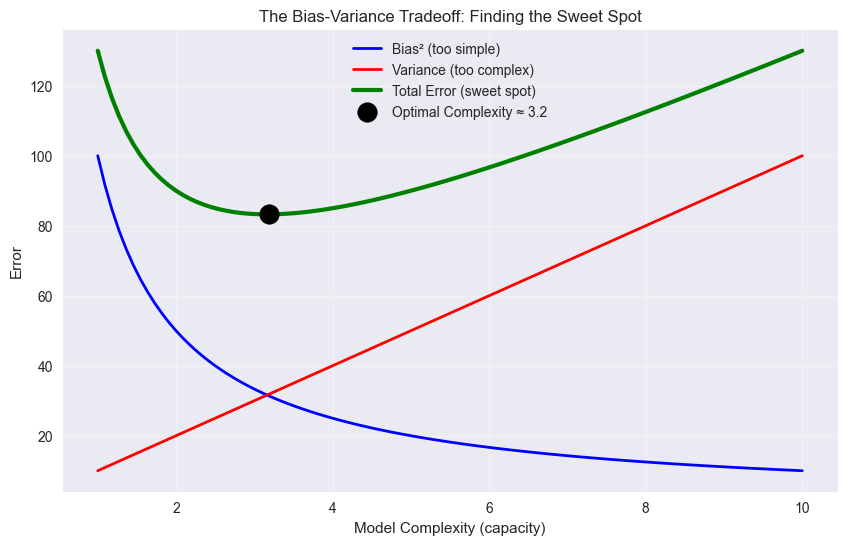

In [8]:
# Visualize the bias-variance tradeoff
complexity = np.linspace(1, 10, 100)
bias_squared = 100 / complexity
variance = 10 * complexity
total_error = bias_squared + variance + 20  # irreducible error

plt.figure(figsize = (10, 6))
plt.plot(complexity, bias_squared, 'b-', linewidth = 2, label = 'Bias² (too simple)')
plt.plot(complexity, variance, 'r-', linewidth = 2, label = 'Variance (too complex)')
plt.plot(complexity, total_error, 'g-', linewidth = 3, label = 'Total Error (sweet spot)')

# Find optimal complexity
optimal_idx = np.argmin(total_error)
plt.scatter(complexity[optimal_idx], total_error[optimal_idx], color = 'black', s = 200, zorder = 5, 
           label = f'Optimal Complexity ≈ {complexity[optimal_idx]:.1f}')

plt.xlabel('Model Complexity (capacity)')
plt.ylabel('Error')
plt.title('The Bias-Variance Tradeoff: Finding the Sweet Spot')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

**`Maria's Insight:`** "So Peter needs to study enough to understand the material (low bias), but not so much that he memorizes every tiny detail of practice questions (low variance). It's about finding the sweet spot!"
### **6. Fix #1: L2 Regularization (Weight Penalty)**

The first technique to prevent overfitting: **L2 regularization**. It adds a penalty for large weights to the loss function:

$$L = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y})^2 + \lambda \sum w_j^2$$

This says: "Large weights are suspicious. Prefer simpler explanations unless the data strongly justifies complexity."

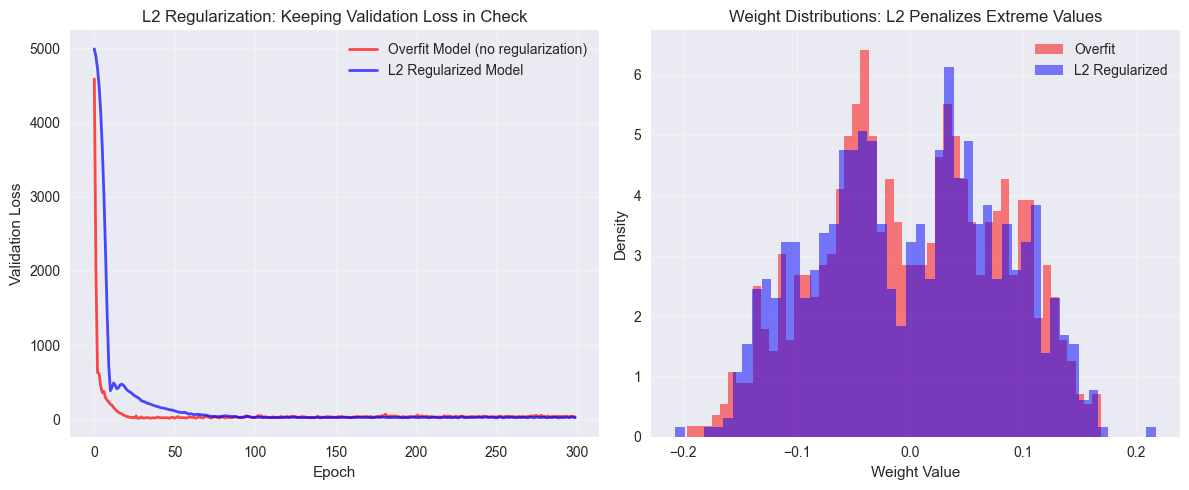

Overfit Model Final Validation Loss: 32.22
L2 Model Final Validation Loss: 20.40
Improvement: 11.82


In [9]:
# Build model with L2 regularization
l2_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation = 'relu', 
                          kernel_regularizer = regularizers.l2(0.01),
                          input_shape = (3,),
                          name = 'l2_layer1'),
    tf.keras.layers.Dense(256, activation = 'relu',
                          kernel_regularizer = regularizers.l2(0.01),
                          name = 'l2_layer2'),
    tf.keras.layers.Dense(256, activation = 'relu',
                          kernel_regularizer = regularizers.l2(0.01),
                          name = 'l2_layer3'),
    tf.keras.layers.Dense(1, name = 'output')
])

l2_model.compile(optimizer = 'adam', loss = 'mse')

# Train
history_l2 = l2_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 300, verbose = 0)

# Compare with overfit model
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['val_loss'], 'r-', linewidth = 2, 
                 label= 'Overfit Model (no regularization)', alpha = 0.7)
plt.plot(history_l2.history['val_loss'], 'b-', linewidth = 2, label = 'L2 Regularized Model', alpha = 0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('L2 Regularization: Keeping Validation Loss in Check')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1, 2, 2)
# Compare weight distributions
overfit_weights = overfit_model.get_weights()[0].flatten()
l2_weights = l2_model.get_weights()[0].flatten()

plt.hist(overfit_weights, bins = 50, alpha = 0.5, label = 'Overfit', color = 'red', density = True)
plt.hist(l2_weights, bins = 50, alpha = 0.5, label = 'L2 Regularized', color = 'blue', density = True)
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.title('Weight Distributions: L2 Penalizes Extreme Values')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

final_val_loss_overfit = history_overfit.history['val_loss'][-1]
final_val_loss_l2 = history_l2.history['val_loss'][-1]
print(f"Overfit Model Final Validation Loss: {final_val_loss_overfit:.2f}")
print(f"L2 Model Final Validation Loss: {final_val_loss_l2:.2f}")
print(f"Improvement: {(final_val_loss_overfit - final_val_loss_l2):.2f}")

### **7. Fix #2: Dropout (Force Robust Representations)**

**`Dropout`** randomly turns off neurons during training. This prevents the network from depending too heavily on any single neuron.

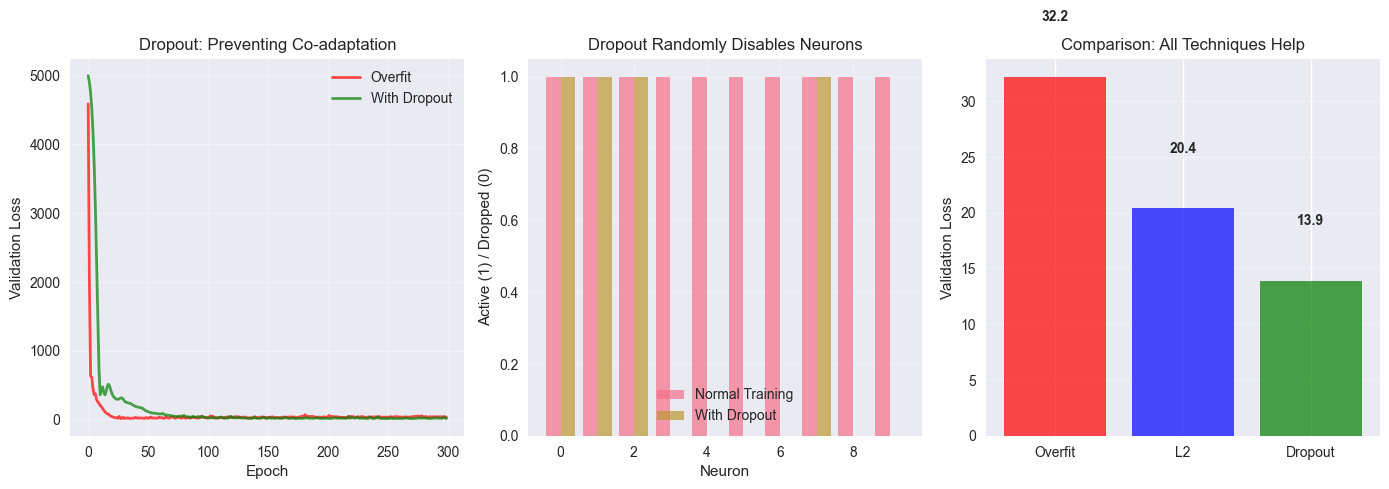

Dropout Model Final Validation Loss: 13.90


In [10]:
# Build model with Dropout
dropout_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation = 'relu', input_shape = (3,), name = 'dropout_layer1'),
    tf.keras.layers.Dropout(0.3, name = 'dropout1'),  # 30% of neurons randomly disabled
    tf.keras.layers.Dense(256, activation = 'relu', name = 'dropout_layer2'),
    tf.keras.layers.Dropout(0.3, name = 'dropout2'),
    tf.keras.layers.Dense(256, activation = 'relu', name = 'dropout_layer3'),
    tf.keras.layers.Dropout(0.3, name = 'dropout3'),
    tf.keras.layers.Dense(1, name = 'output')
])

dropout_model.compile(optimizer = 'adam', loss = 'mse')

# Train
history_dropout = dropout_model.fit(X_train, y_train, validation_data = (X_val, y_val),
                                    epochs = 300,
                                    verbose = 0)

# Visualize Dropout's effect
plt.figure(figsize = (14, 5))

plt.subplot(1, 3, 1)
plt.plot(history_overfit.history['val_loss'], 'r-', linewidth = 2, 
         label = 'Overfit', alpha = 0.7)
plt.plot(history_dropout.history['val_loss'], 'g-', linewidth = 2, 
         label = 'With Dropout', alpha = 0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Dropout: Preventing Co-adaptation')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1, 3, 2)
# Simulate dropout during inference (it's automatically disabled)
# But we can visualize the concept
neurons = np.arange(10)
active_normal = np.ones(10)
active_dropout = np.random.binomial(1, 0.7, 10)  # 30% dropout rate

plt.bar(neurons - 0.2, active_normal, width = 0.4, label = 'Normal Training', alpha = 0.7)
plt.bar(neurons + 0.2, active_dropout, width = 0.4, label = 'With Dropout', alpha = 0.7)
plt.xlabel('Neuron')
plt.ylabel('Active (1) / Dropped (0)')
plt.title('Dropout Randomly Disables Neurons')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1, 3, 3)
# Compare validation performance
models = ['Overfit', 'L2', 'Dropout']
val_losses = [
    history_overfit.history['val_loss'][-1],
    history_l2.history['val_loss'][-1],
    history_dropout.history['val_loss'][-1]
]
colors = ['red', 'blue', 'green']
plt.bar(models, val_losses, color = colors, alpha = 0.7)
plt.ylabel('Validation Loss')
plt.title('Comparison: All Techniques Help')
for i, v in enumerate(val_losses):
    plt.text(i, v + 5, f'{v:.1f}', ha = 'center', fontweight = 'bold')
plt.grid(True, alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.show()

print(f"Dropout Model Final Validation Loss: {history_dropout.history['val_loss'][-1]:.2f}")

### **8. Fix #3: Early Stopping (Know When to Quit)**

The simplest and often most effective technique: **stop training when validation loss starts increasing**.

Epoch 167: early stopping
Restoring model weights from the end of the best epoch: 147.


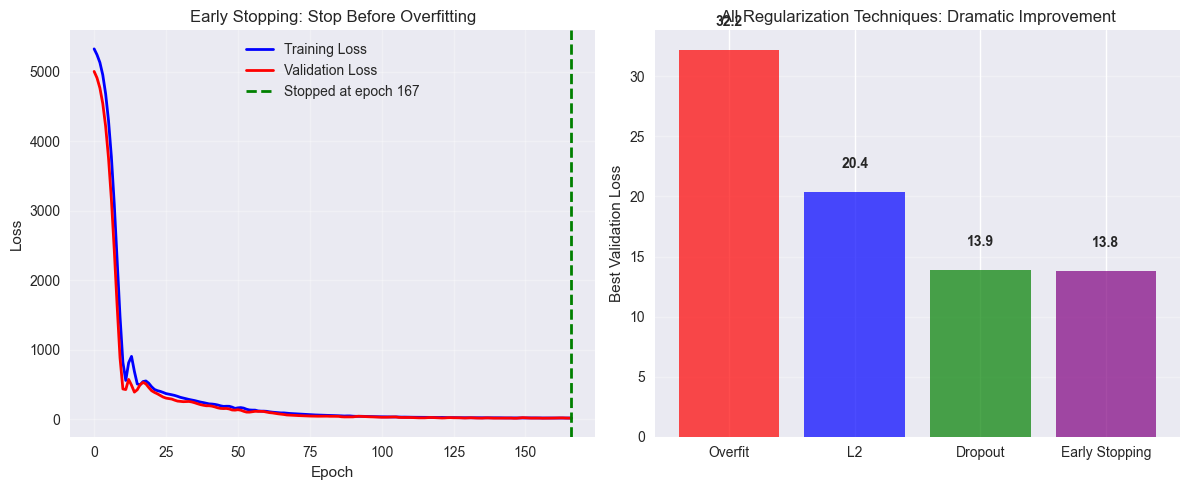

Early stopping triggered at epoch 167
Best validation loss achieved: 13.77


In [11]:
# Early stopping callback
early_stop = EarlyStopping(
                monitor = 'val_loss',      # Watch validation loss
                patience = 20,              # Stop after 20 epochs of no improvement
                restore_best_weights = True, # Go back to the best model
                verbose = 1
            )

# Train with early stopping
early_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation = 'relu', input_shape = (3,)),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(1)
])
early_model.compile(optimizer = 'adam', loss = 'mse')

history_early = early_model.fit(
                    X_train, y_train,
                    validation_data = (X_val, y_val),
                    epochs = 300,
                    callbacks = [early_stop],
                    verbose = 0
                )

# Visualize early stopping
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_early.history['loss'], 'b-', linewidth = 2, label ='Training Loss')
plt.plot(history_early.history['val_loss'], 'r-', linewidth = 2, label = 'Validation Loss')
plt.axvline(x = len(history_early.history['loss'])-1, 
            color = 'green', linestyle = '--', linewidth = 2,
            label = f"Stopped at epoch {len(history_early.history['loss'])}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Early Stopping: Stop Before Overfitting')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1, 2, 2)
# Compare all techniques
techniques = ['Overfit', 'L2', 'Dropout', 'Early Stopping']
losses = [
    history_overfit.history['val_loss'][-1],
    history_l2.history['val_loss'][-1],
    history_dropout.history['val_loss'][-1],
    min(history_early.history['val_loss'])  # Best validation loss
]
colors = ['red', 'blue', 'green', 'purple']

bars = plt.bar(techniques, losses, color = colors, alpha = 0.7)
plt.ylabel('Best Validation Loss')
plt.title('All Regularization Techniques: Dramatic Improvement')
for bar, loss in zip(bars, losses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{loss:.1f}', ha = 'center', fontweight = 'bold')
plt.grid(True, alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.show()

stopped_epoch = len(history_early.history['loss'])
best_val_loss = min(history_early.history['val_loss'])
print(f"Early stopping triggered at epoch {stopped_epoch}")
print(f"Best validation loss achieved: {best_val_loss:.2f}")

### **9. The Complete Picture: All Techniques Combined**

Let's build Peter's ultimate brain — one that generalizes well to new tests:

Peter's Ultimate Brain: Production-Ready Model
Final Validation MSE: 68.00

Techniques Used:
• Moderate network size (not too big, not too small)
• L2 regularization (penalizes extreme weights)
• Dropout (forces robust representations)
• Early stopping (quits before overfitting)


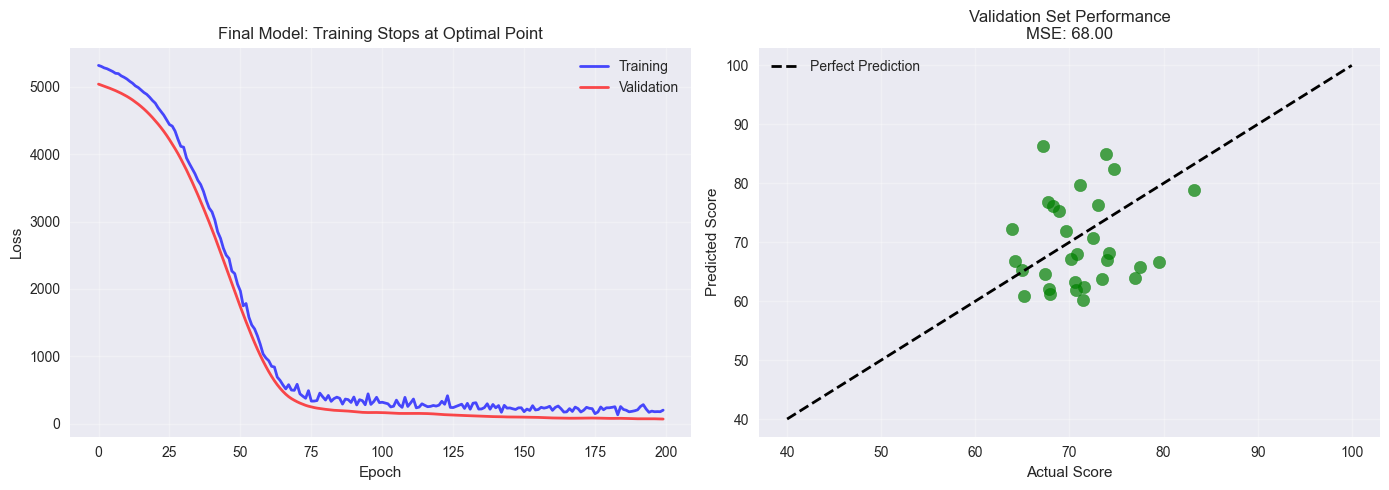

In [12]:
# Build production-ready model with all techniques
final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation = 'relu', 
                          kernel_regularizer = regularizers.l2(0.001),
                          input_shape = (3,),
                          name = 'layer1'),
    tf.keras.layers.Dropout(0.2, name = 'dropout1'),
    tf.keras.layers.Dense(32, activation = 'relu',
                          kernel_regularizer = regularizers.l2(0.001),
                          name = 'layer2'),
    tf.keras.layers.Dropout(0.2, name = 'dropout2'),
    tf.keras.layers.Dense(1, name = 'output')
])

final_model.compile(optimizer = 'adam', loss = 'mse')

# Train with early stopping
final_history = final_model.fit(
                    X_train, y_train,
                    validation_data = (X_val, y_val),
                    epochs = 200,
                    callbacks = [EarlyStopping(monitor = 'val_loss', patience = 15, restore_best_weights = True)],
                    verbose = 0
                )

# Evaluate on validation set
val_predictions = final_model.predict(X_val, verbose = 0)
val_mse = np.mean((y_val - val_predictions.flatten()) ** 2)

print("Peter's Ultimate Brain: Production-Ready Model")
print("="*60)
print(f"Final Validation MSE: {val_mse:.2f}")
print("\nTechniques Used:")
print("• Moderate network size (not too big, not too small)")
print("• L2 regularization (penalizes extreme weights)")
print("• Dropout (forces robust representations)")
print("• Early stopping (quits before overfitting)")

# Visualize final results
plt.figure(figsize = (14, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history['loss'], 'b-', linewidth = 2, label = 'Training', alpha = 0.7)
plt.plot(final_history.history['val_loss'], 'r-', linewidth = 2, label = 'Validation', alpha = 0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model: Training Stops at Optimal Point')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_val, val_predictions, alpha = 0.7, s = 80, c = 'green')
plt.plot([40, 100], [40, 100], 'k--', linewidth = 2, label = 'Perfect Prediction')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title(f'Validation Set Performance\nMSE: {val_mse:.2f}')
plt.legend()
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

### **10. What Maria Learned About Generalization**

In [13]:
generalization_lessons = [
    ("Training Loss", "How well Peter memorized past tests", 
     "Can be misleadingly low"),
    ("Validation Loss", "How Peter will do on new tests", 
     "The only metric that matters for real-world use"),
    ("Overfitting", "Memorizing noise instead of learning patterns", 
     "Training loss good, validation loss bad"),
    ("L2 Regularization", "Penalizing extreme study habits", 
     "Keeps weights small and stable"),
    ("Dropout", "Randomly forgetting during practice", 
     "Prevents over-reliance on any one strategy"),
    ("Early Stopping", "Knowing when to stop studying", 
     "Stops before memorization begins"),
    ("Bias-Variance Tradeoff", "Balance between understanding and memorizing", 
     "Sweet spot for generalization")
]

print("="*80)
print("WHAT MARIA LEARNED ABOUT GENERALIZATION")
print("="*80)

for concept, analogy, insight in generalization_lessons:
    print(f"\n📌 {concept}")
    print(f"   • Peter Analogy: {analogy}")
    print(f"   • Key Insight: {insight}")

WHAT MARIA LEARNED ABOUT GENERALIZATION

📌 Training Loss
   • Peter Analogy: How well Peter memorized past tests
   • Key Insight: Can be misleadingly low

📌 Validation Loss
   • Peter Analogy: How Peter will do on new tests
   • Key Insight: The only metric that matters for real-world use

📌 Overfitting
   • Peter Analogy: Memorizing noise instead of learning patterns
   • Key Insight: Training loss good, validation loss bad

📌 L2 Regularization
   • Peter Analogy: Penalizing extreme study habits
   • Key Insight: Keeps weights small and stable

📌 Dropout
   • Peter Analogy: Randomly forgetting during practice
   • Key Insight: Prevents over-reliance on any one strategy

📌 Early Stopping
   • Peter Analogy: Knowing when to stop studying
   • Key Insight: Stops before memorization begins

📌 Bias-Variance Tradeoff
   • Peter Analogy: Balance between understanding and memorizing
   • Key Insight: Sweet spot for generalization


### **Final Thoughts: The Only Thing That Matters**

Maria’s final realization:

> “I used to think a good model was one that perfectly predicted past scores.
> Now I understand — that can actually be a warning sign.
> The only thing that truly matters is how well Peter’s Brain performs on **tests it has never seen before**.”

This insight captures the fundamental principle of machine learning:

* A model that **memorizes the training data** is not useful.
* A model that **captures the underlying structure of the data** is valuable.
* **Generalization performance** — not training performance — is the real objective.

That is why machine learning practitioners rely on **validation datasets**.

They simulate the **future**.

They reveal whether the model has learned **patterns** or merely **memorized noise**.

To encourage generalization, we introduced three key tools:

* **L2 Regularization** – discourages overly large weights and encourages simpler explanations.
* **Dropout** – forces the network to learn robust representations instead of relying on individual neurons.
* **Early Stopping** – halts training before memorization begins.

These techniques do not make the model *smarter*.

They simply **restrict the ways it is allowed to learn**, forcing it toward patterns that generalize.

Ultimately, Peter’s Brain is not trying to memorize past scores.

It is trying to **approximate the hidden function** that generates them — the true relationship between:

* sleep
* study habits
* prior performance
* and exam outcomes.

In machine learning terms, the goal is to learn a function:

$f(x) \approx y$

that performs well **not only on observed data, but on unseen data drawn from the same process.**

That distinction — between **memorization and approximation** — is everything.

Maria leaned back and smiled.

“Peter’s Brain can finally generalize.”

But she still had one question.

> “The model improved its predictions during training…
> but **how did it know which weights to change?**”

How did the network determine:

* which parameters to increase
* which ones to decrease
* and by how much?

Behind the scenes, a powerful mathematical engine was guiding every update.

An algorithm that follows the slope of the error surface.

An algorithm called **Gradient Descent**.

And understanding it reveals the real mechanism behind neural network learning.

→ **Part 3: How Gradient Descent Actually Trains Neural Networks**

In the next tutorial we will explore:

* The **loss landscape**
* Why gradients point toward improvement
* How **backpropagation applies the chain rule**
* Why optimization works even in **high-dimensional parameter spaces**

And we’ll finally see how Peter’s Brain **learns from its mistakes using calculus.**


### **Summary: The Complete Picture**

| Concept | What It Means | How We Fix It |
|---------|--------------|---------------|
| **Overfitting** | Model learns noise, not signal | Regularization, dropout, early stopping |
| **Underfitting** | Model too simple to capture patterns | Increase capacity, train longer |
| **Bias** | Systematic error from wrong assumptions | More complex models, feature engineering |
| **Variance** | Sensitivity to training data fluctuations | Regularization, more data |
| **Generalization** | Performance on new, unseen data | Validation sets, cross-validation |

👏 **Congratulations!** 👏

You now understand not just how neural networks learn, but **how to make them learn the right things** — the patterns that generalize to new situations.

In the next chapter, we will open the black box and examine the **mathematics that actually drives learning.**

Peter’s journey continues.